In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import cv2
import hashlib
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import os

from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/My Drive/DSGP/Data"
print(os.listdir(dataset_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['eczema', 'ringworm', 'acne']


EDA

In [3]:
# This code loads all images with their labels into a DataFrame and shows class counts.
import os
import pandas as pd

classes = sorted(os.listdir(dataset_path))

data = []
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for img in os.listdir(cls_path):
        data.append([os.path.join(cls_path, img), cls])

# Convert the collected data into a Pandas DataFrame
df = pd.DataFrame(data, columns=["image_path", "label"])

print(df["label"].value_counts())

label
acne        982
ringworm    971
eczema      939
Name: count, dtype: int64


In [4]:
# This code checks the different image sizes in the dataset and counts how many images have each size.
sizes = []

for path in df["image_path"]:
    img = Image.open(path)
    sizes.append(img.size)

pd.Series(sizes).value_counts().head()

,count
"(1024, 1024)",982
"(720, 472)",472
"(720, 480)",241
"(477, 720)",200
"(480, 720)",124


In [5]:
# This code analyzes the brightness levels of images in the dataset.
brightness = []
for path in df["image_path"]:
    img = Image.open(path).convert("L")
    brightness.append(np.array(img).mean())

pd.Series(brightness).describe()

,0
count,2892.000000
mean,104.043887
std,25.686854
min,16.155195
25%,87.395862
50%,101.808476
75%,120.867898
max,206.733511


In [6]:
# This code checks the aspect ratio (width to height) of images in the dataset.
aspect_ratios = []

for path in df["image_path"]:
    img = Image.open(path)
    w, h = img.size
    aspect_ratios.append(round(w / h, 2))

pd.Series(aspect_ratios).value_counts().head()

,count
1.00,982
1.53,518
1.50,271
0.66,265
0.67,163


In [8]:
import numpy as np

brightness = []

for path in df["image_path"]:
    img = Image.open(path).convert("L")  # grayscale
    brightness.append(np.array(img).mean())

pd.Series(brightness).describe()

,0
count,2892.000000
mean,104.043887
std,25.686854
min,16.155195
25%,87.395862
50%,101.808476
75%,120.867898
max,206.733511


In [9]:
# This code analyzes the average Red, Green, and Blue color intensity in the images.
r, g, b = [], [], []

for path in df["image_path"]:
    img = Image.open(path).resize((64,64))
    arr = np.array(img)
    r.append(arr[:,:,0].mean())
    g.append(arr[:,:,1].mean())
    b.append(arr[:,:,2].mean())

print("R mean:", np.mean(r))
print("G mean:", np.mean(g))
print("B mean:", np.mean(b))

R mean: 127.38140278205502
G mean: 96.07703599098807
B mean: 83.85088343112466


VISUALIZATION

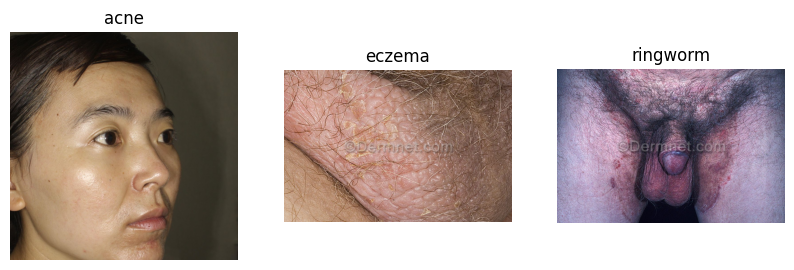

In [10]:
# This code displays one sample image from each class to visually inspect the dataset.
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(10,6))
for i, cls in enumerate(classes):
    img_path = random.choice(df[df["label"] == cls]["image_path"].values)
    img = Image.open(img_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

DATA CLEANING

In [11]:
#Remove Corrupted Images
def remove_corrupted_images(dataset_path):
    removed = 0
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        for img in os.listdir(cls_path):
            try:
                Image.open(os.path.join(cls_path, img)).verify()
            except:
                os.remove(os.path.join(cls_path, img))
                removed += 1
    print("Removed corrupted images:", removed)

remove_corrupted_images(dataset_path)

Removed corrupted images: 0


In [12]:
# This code converts all images to RGB format to ensure consistent input for the model.
def convert_to_rgb(dataset_path):
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            if img.mode != "RGB":
                img.convert("RGB").save(img_path)

convert_to_rgb(dataset_path)

In [13]:
# This code removes duplicate images by comparing their file content using hashes.
hashes = {}
for path in df["image_path"]:
    h = hashlib.md5(open(path,'rb').read()).hexdigest()
    if h in hashes:
        os.remove(path)
    else:
        hashes[h] = path

In [14]:
#Remove non-image files

valid_ext = (".jpg", ".jpeg", ".png")

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for file in os.listdir(cls_path):
        if not file.lower().endswith(valid_ext):
            os.remove(os.path.join(cls_path, file))


In [15]:
# This code converts class names into numerical labels for model training.
label_map = {cls: i for i, cls in enumerate(classes)}
df["label_encoded"] = df["label"].map(label_map)

print(label_map)

{'acne': 0, 'eczema': 1, 'ringworm': 2}


In [16]:
# This code rebuilds the dataset after cleaning and counts the remaining images.
import os
import pandas as pd

data = []
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for img in os.listdir(cls_path):
        full_path = os.path.join(cls_path, img)
        data.append([full_path, cls])

df = pd.DataFrame(data, columns=["image_path", "label"])
print("Total images after cleaning:", len(df))


Total images after cleaning: 2892


In [17]:
# This code detects duplicate images in the dataset by comparing their hash values.
import hashlib

def image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for path in df["image_path"]:
    h = image_hash(path)
    if h in hashes:
        duplicates.append(path)
    else:
        hashes[h] = path

print("Duplicate images found:", len(duplicates))


Duplicate images found: 0


In [18]:
# This code removes very small images that are not useful for model training.
MIN_SIZE = 100  # pixels

for path in df["image_path"]:
    img = Image.open(path)
    w, h = img.size
    if w < MIN_SIZE or h < MIN_SIZE:
        os.remove(path)

In [19]:
# This code rebuilds the dataset by collecting updated image paths and labels after cleaning.
data = []
for cls in classes:
    for img in os.listdir(os.path.join(dataset_path, cls)):
        data.append([os.path.join(dataset_path, cls, img), cls])

df = pd.DataFrame(data, columns=["image_path", "label"])

preprocessing

In [20]:
# This code converts severity class names into numbers for training the model.
label_map = {cls: i for i, cls in enumerate(classes)}
df["label_encoded"] = df["label"].map(label_map)

# Quick check
df.head()


,image_path,label,label_encoded
0,/content/drive/My Drive/DSGP/Data/acne/levle1_...,acne,0
1,/content/drive/My Drive/DSGP/Data/acne/levle3_...,acne,0
2,/content/drive/My Drive/DSGP/Data/acne/levle0_...,acne,0
3,/content/drive/My Drive/DSGP/Data/acne/levle2_...,acne,0
4,/content/drive/My Drive/DSGP/Data/acne/levle2_...,acne,0


In [21]:
# This code splits the dataset into 60% training, 20% validation, and 20% testing while preserving class balance.
from sklearn.model_selection import train_test_split

# Train 60%, Temp 40%
train_df, temp_df = train_test_split(
    df,
    test_size=0.4,
    stratify=df["label_encoded"],
    random_state=42
)

# Temp 40% -> Val 20%, Test 20%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_encoded"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 1735
Validation: 578
Test: 579


In [22]:
# This code loads images, resizes them, and normalizes pixel values for model training.
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load and preprocess image
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


In [23]:
# This code creates TensorFlow datasets for training, validation, and testing with batching and prefetching.
# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values,
     train_df["label_encoded"].values)
)

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values,
     val_df["label_encoded"].values)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values,
     test_df["label_encoded"].values)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Sanity check
for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)


(32, 224, 224, 3) (32,)


model training


In [24]:
# This code builds a CNN model to classify images into three severity levels.
NUM_CLASSES = 3
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),   # input image

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),                 # reduce overfitting

    layers.Dense(NUM_CLASSES, activation='softmax')  # 3 classes
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# This code compiles the CNN model with optimizer, loss function, and accuracy metric.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # integer labels
    metrics=['accuracy']
)


In [28]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.7599 - loss: 0.5291 - val_accuracy: 0.7024 - val_loss: 0.5146
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 264s 5s/step - accuracy: 0.7406 - loss: 0.4873 - val_accuracy: 0.7457 - val_loss: 0.4615
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.7893 - loss: 0.4294 - val_accuracy: 0.7630 - val_loss: 0.4797
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.7969 - loss: 0.4442 - val_accuracy: 0.7595 - val_loss: 0.4493
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 249s 4s/step - accuracy: 0.8101 - loss: 0.3908 - val_accuracy: 0.7855 - val_loss: 0.4355
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.8310 - loss: 0.3451 - val_accuracy: 0.7872 - val_loss: 0.4105
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.8517 - loss: 0.3264 - val_accuracy: 0.7837 - val_loss: 0.4378
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.8350 - loss: 0.3417 - val_accuracy: 0.7785 - v

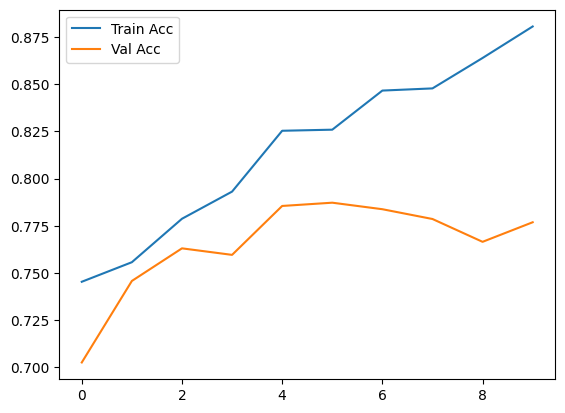

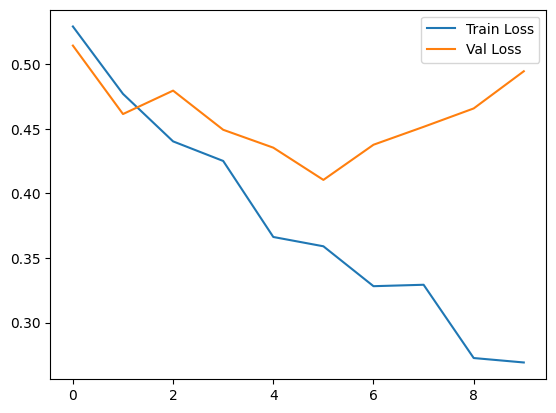

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


In [30]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7926 - loss: 0.4503
Test Accuracy: 0.7806562781333923


In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step
[[195   0   2]
 [  1 100  87]
 [  1  36 157]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       197
           1       0.74      0.53      0.62       188
           2       0.64      0.81      0.71       194

    accuracy                           0.78       579
   macro avg       0.79      0.78      0.77       579
weighted avg       0.79      0.78      0.78       579

